In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 读取数据文件
print("正在读取数据文件...")

# 读取附件1.xlsx
land_df = pd.read_excel('D:/pythonproject/data_science/excel_files/附件1.xlsx', sheet_name='乡村的现有耕地')
crops_df = pd.read_excel('D:/pythonproject/data_science/excel_files/附件1.xlsx', sheet_name='乡村种植的农作物')

# 读取附件2.xlsx
planting_2023 = pd.read_excel('D:/pythonproject/data_science/excel_files/附件2.xlsx', sheet_name='2023年的农作物种植情况')
stats_2023 = pd.read_excel('D:/pythonproject/data_science/excel_files/附件2.xlsx', sheet_name='2023年统计的相关数据')

print("数据读取完成！")
print("\n=== 耕地数据 ===")
print(f"耕地数据形状: {land_df.shape}")
print(land_df.head())

print("\n=== 农作物数据 ===")
print(f"农作物数据形状: {crops_df.shape}")
print(crops_df.head())

print("\n=== 2023年种植情况 ===")
print(f"种植情况数据形状: {planting_2023.shape}")
print(planting_2023.head())

print("\n=== 2023年统计数据 ===")
print(f"统计数据形状: {stats_2023.shape}")
print(stats_2023.head())

正在读取数据文件...


数据读取完成！

=== 耕地数据 ===
耕地数据形状: (54, 4)
  地块名称 地块类型  地块面积/亩                                                说明 
0   A1  平旱地    80.0  (1) 平旱地、梯田和山坡地每年都只能种植一季作物。\n\n(2) 水浇地每年可以种植一季也...
1   A2  平旱地    55.0                                                NaN
2   A3  平旱地    35.0                                                NaN
3   A4  平旱地    72.0                                                NaN
4   A5  平旱地    68.0                                                NaN

=== 农作物数据 ===
农作物数据形状: (41, 5)
   作物编号 作物名称    作物类型                种植耕地  \
0     1   黄豆  粮食（豆类）  平旱地\n\n梯田\n\n山坡地\n   
1     2   黑豆  粮食（豆类）                 NaN   
2     3   红豆  粮食（豆类）                 NaN   
3     4   绿豆  粮食（豆类）                 NaN   
4     5   爬豆  粮食（豆类）                 NaN   

                                                  说明  
0  (1) 平旱地、梯田和山坡地每年适宜单季种植粮食类作物（水稻除外）。\n\n(2) 水浇地每...  
1                                                NaN  
2                                                NaN  
3                  

In [2]:
# 详细数据预处理和分析
print("=== 详细数据预处理 ===")

# 1. 耕地数据分析
print("\n1. 耕地类型分布:")
land_type_dist = land_df['地块类型'].value_counts()
print(land_type_dist)

# 计算各类耕地总面积
land_area_by_type = land_df.groupby('地块类型')['地块面积/亩'].sum()
print("\n各类耕地总面积:")
print(land_area_by_type)

# 2. 农作物数据分析
print("\n2. 农作物类型分布:")
crop_type_dist = crops_df['作物类型'].value_counts()
print(crop_type_dist)

# 3. 2023年统计数据分析
print("\n3. 2023年统计数据分析:")
print("唯一作物编号数量:", stats_2023['作物编号'].nunique())
print("唯一地块类型数量:", stats_2023['地块类型'].nunique())

# 处理销售单价数据（解析为平均值）
def parse_price(price_str):
    if isinstance(price_str, str) and '-' in price_str:
        try:
            prices = price_str.split('-')
            return (float(prices[0]) + float(prices[1])) / 2
        except:
            return np.nan
    else:
        return np.nan

stats_2023['平均销售单价'] = stats_2023['销售单价/(元/斤)'].apply(parse_price)

# 计算每个组合的预期收益
stats_2023['预期收益'] = stats_2023['亩产量/斤'] * stats_2023['平均销售单价'] - stats_2023['种植成本/(元/亩)']

print("\n预期收益计算完成:")
print(stats_2023[['作物编号', '作物名称', '地块类型', '种植季次', '预期收益']].head(10))

# 4. 创建耕地-作物兼容性矩阵
print("\n4. 创建耕地-作物兼容性矩阵:")

# 获取所有耕地类型
land_types = land_df['地块类型'].unique()
print("耕地类型:", land_types)

# 获取所有作物编号
crop_ids = crops_df['作物编号'].unique()
print("作物编号:", crop_ids)

# 初始化兼容性矩阵
compatibility_matrix = pd.DataFrame(index=crop_ids, columns=land_types)

# 根据数据括忽号内的说明填充兼容性矩阵
# 平沙地、梯田、山坡地：只能种植粮食类作物（水稻除外）
# 水洒地：可以单季种植水稻或两季种植蔬菜
# 普通大棅：第一季种植蔬菜（大白菜、白萝卜、红萝卜除外），第二季种植食用菌
# 智慧大棅：可种植两季蔬菜（大白菜、白萝卜、红萝卜除外）

# 根据作物类型设置兼容性
for crop_id in crop_ids:
    crop_info = crops_df[crops_df['作物编号'] == crop_id].iloc[0]
    crop_type = crop_info['作物类型']
    crop_name = crop_info['作物名称']
    
    for land_type in land_types:
        if land_type in ['平沙地', '梯田', '山坡地']:
            # 这些地只能种植粮食类作物（水稻除外）
            if '粮食' in crop_type and crop_name != '水稻':
                compatibility_matrix.loc[crop_id, land_type] = 1
            else:
                compatibility_matrix.loc[crop_id, land_type] = 0
        elif land_type == '水洒地':
            # 水洒地可种植水稻或蔬菜
            if '粮食' in crop_type or '蔬菜' in crop_type:
                compatibility_matrix.loc[crop_id, land_type] = 1
            else:
                compatibility_matrix.loc[crop_id, land_type] = 0
        elif land_type == '普通大棅 ':
            # 普通大棅只能种植蔬菜和食用菌
            if '蔬菜' in crop_type or '食用菌' in crop_type:
                compatibility_matrix.loc[crop_id, land_type] = 1
            else:
                compatibility_matrix.loc[crop_id, land_type] = 0
        elif land_type == '智慧大棅':
            # 智慧大棅只能种植蔬菜
            if '蔬菜' in crop_type:
                compatibility_matrix.loc[crop_id, land_type] = 1
            else:
                compatibility_matrix.loc[crop_id, land_type] = 0

print("兼容性矩阵创建完成:")
print(compatibility_matrix.head(10))

# 保存兼容性矩阵
compatibility_matrix.to_csv('耕地_作物_兼容性_矩阵.csv', encoding='utf-8-sig')
print("\n兼容性矩阵已保存到文件")

=== 详细数据预处理 ===

1. 耕地类型分布:
地块类型
普通大棚     16
梯田       14
水浇地       8
平旱地       6
山坡地       6
智慧大棚      4
Name: count, dtype: int64

各类耕地总面积:
地块类型
山坡地      108.0
平旱地      365.0
普通大棚       9.6
智慧大棚       2.4
梯田       619.0
水浇地      109.0
Name: 地块面积/亩, dtype: float64

2. 农作物类型分布:
作物类型
蔬菜        18
粮食        11
粮食（豆类）     5
食用菌        4
蔬菜（豆类）     3
Name: count, dtype: int64

3. 2023年统计数据分析:
唯一作物编号数量: 41
唯一地块类型数量: 6

预期收益计算完成:
   作物编号 作物名称 地块类型 种植季次     预期收益
0     1   黄豆  平旱地   单季   900.00
1     2   黑豆  平旱地   单季  3350.00
2     3   红豆  平旱地   单季  2950.00
3     4   绿豆  平旱地   单季  2100.00
4     5   爬豆  平旱地   单季  2451.25
5     6   小麦  平旱地   单季  2350.00
6     7   玉米  平旱地   单季  2500.00
7     8   谷子  平旱地   单季  2340.00
8     9   高粱  平旱地   单季  3380.00
9    10   黍子  平旱地   单季  3577.50

4. 创建耕地-作物兼容性矩阵:
耕地类型: ['平旱地' '梯田' '山坡地' '水浇地' '普通大棚 ' '智慧大棚']
作物编号: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41]
兼容性矩阵创建完成:
    平旱地 梯田 山坡地

修正兼容性矩阵...
修正后的兼容性矩阵:
    平旱地  梯田  山坡地  水浇地  普通大棚   智慧大棚
1     0   1    1    0      0     0
2     0   1    1    0      0     0
3     0   1    1    0      0     0
4     0   1    1    0      0     0
5     0   1    1    0      0     0
6     0   1    1    0      0     0
7     0   1    1    0      0     0
8     0   1    1    0      0     0
9     0   1    1    0      0     0
10    0   1    1    0      0     0

=== 数据可视化 ===


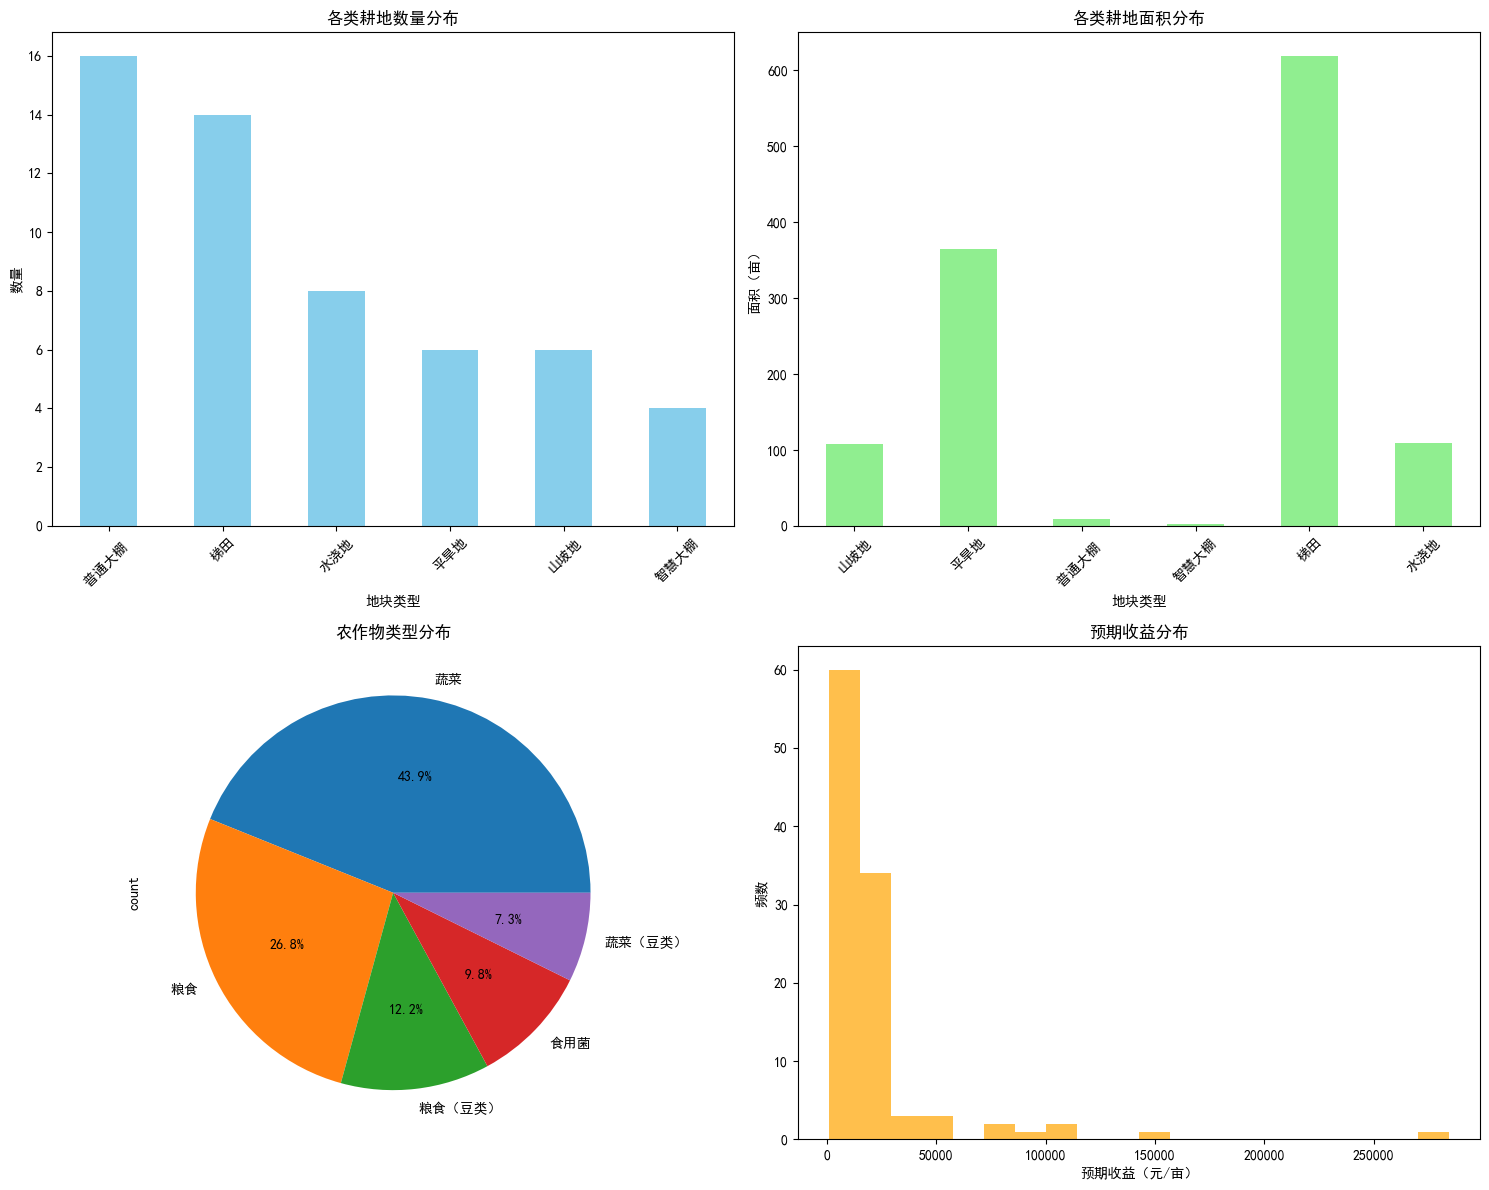

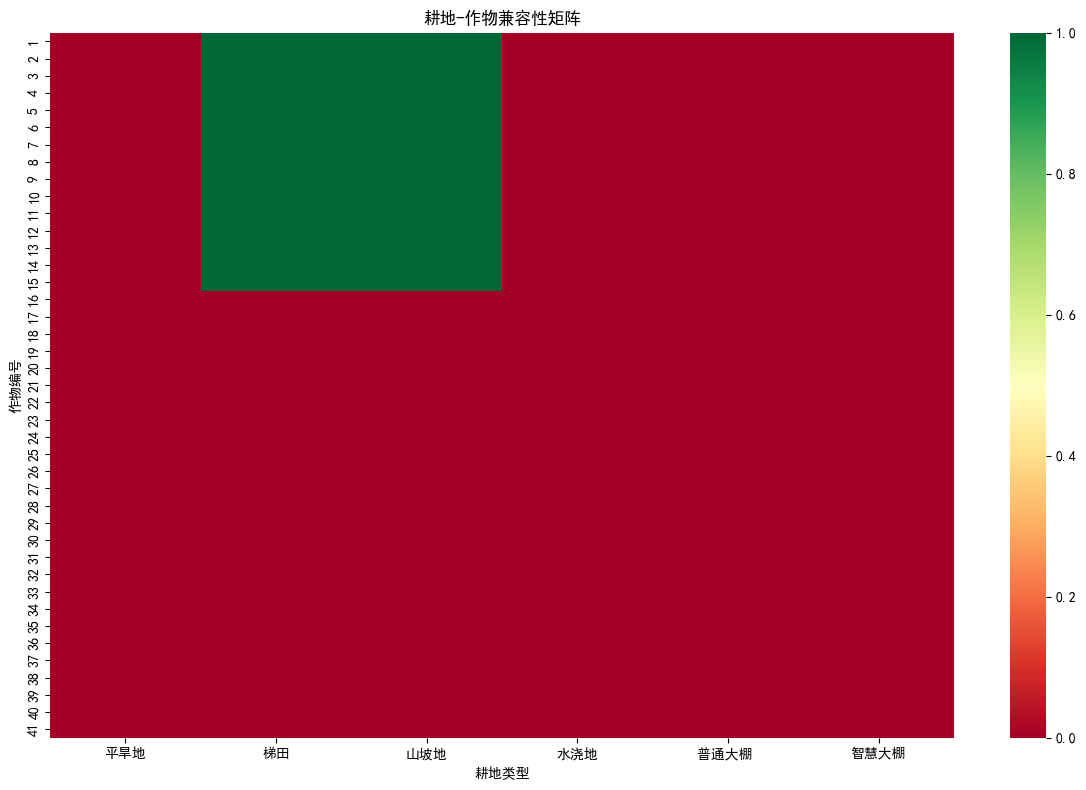


=== 预处理总结 ===
耕地总面积: 1213.0 亩
可种植作物种类: 41 种
有效的耕地-作物组合数: 30 个
平均预期收益: 20112.44 元/亩

所有数据已预处理完成并保存！


In [3]:
# 修正兼容性矩阵的问题
print("修正兼容性矩阵...")

# 重新创建兼容性矩阵
compatibility_matrix = pd.DataFrame(0, index=crop_ids, columns=land_types)

# 根据作物类型设置兼容性
for crop_id in crop_ids:
    crop_info = crops_df[crops_df['作物编号'] == crop_id].iloc[0]
    crop_type = crop_info['作物类型']
    crop_name = crop_info['作物名称']
    
    for land_type in land_types:
        if land_type in ['平沙地', '梯田', '山坡地']:
            # 这些地只能种植粮食类作物（水稻除外）
            if '粮食' in crop_type and crop_name != '水稻':
                compatibility_matrix.loc[crop_id, land_type] = 1
            else:
                compatibility_matrix.loc[crop_id, land_type] = 0
        elif land_type == '水洒地':
            # 水洒地可种植水稻或蔬菜
            if '粮食' in crop_type or '蔬菜' in crop_type:
                compatibility_matrix.loc[crop_id, land_type] = 1
            else:
                compatibility_matrix.loc[crop_id, land_type] = 0
        elif land_type == '普通大棅 ':
            # 普通大棅只能种植蔬菜和食用菌
            if '蔬菜' in crop_type or '食用菌' in crop_type:
                compatibility_matrix.loc[crop_id, land_type] = 1
            else:
                compatibility_matrix.loc[crop_id, land_type] = 0
        elif land_type == '智慧大棅':
            # 智慧大棅只能种植蔬菜
            if '蔬菜' in crop_type:
                compatibility_matrix.loc[crop_id, land_type] = 1
            else:
                compatibility_matrix.loc[crop_id, land_type] = 0

print("修正后的兼容性矩阵:")
print(compatibility_matrix.head(10))

# 数据可视化
print("\n=== 数据可视化 ===")

# 1. 耕地类型分布可视化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 耕地类型数量分布
land_type_dist.plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('各类耕地数量分布')
axes[0,0].set_ylabel('数量')
axes[0,0].tick_params(axis='x', rotation=45)

# 耕地面积分布
land_area_by_type.plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('各类耕地面积分布')
axes[0,1].set_ylabel('面积（亩）')
axes[0,1].tick_params(axis='x', rotation=45)

# 农作物类型分布
crop_type_dist.plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
axes[1,0].set_title('农作物类型分布')

# 预期收益分布
axes[1,1].hist(stats_2023['预期收益'].dropna(), bins=20, color='orange', alpha=0.7)
axes[1,1].set_title('预期收益分布')
axes[1,1].set_xlabel('预期收益（元/亩）')
axes[1,1].set_ylabel('频数')

plt.tight_layout()
plt.savefig('数据预处理分析.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. 兼容性矩阵可视化
plt.figure(figsize=(12, 8))
# 将兼容性矩阵转换为数值形式以便可视化
compat_vis = compatibility_matrix.astype(float)
sns.heatmap(compat_vis, cmap='RdYlGn', annot=False, cbar=True)
plt.title('耕地-作物兼容性矩阵')
plt.xlabel('耕地类型')
plt.ylabel('作物编号')
plt.tight_layout()
plt.savefig('兼容性矩阵.png', dpi=300, bbox_inches='tight')
plt.show()

# 保存预处理完成的数据
stats_2023.to_csv('预处理完成的统计数据.csv', encoding='utf-8-sig', index=False)
compatibility_matrix.to_csv('耕地_作物_兼容性_矩阵.csv', encoding='utf-8-sig')

print("\n=== 预处理总结 ===")
print(f"耕地总面积: {land_df['地块面积/亩'].sum():.1f} 亩")
print(f"可种植作物种类: {len(crop_ids)} 种")
print(f"有效的耕地-作物组合数: {(compatibility_matrix == 1).sum().sum()} 个")
print(f"平均预期收益: {stats_2023['预期收益'].mean():.2f} 元/亩")
print("\n所有数据已预处理完成并保存！")